# Perceptron
### Definition
The Perceptron is a classical machine learning classification model foundational to the rest of the machine learning field. It consists of a single neuron with weights and a bias, and a binary output.
Based on the computed z, the binary output is given by the following simple activation function: 
$$
f(z) = \begin{cases}
  1 & \text{if} & z \geq 0 \\
  -1 & \text{if} & z < 0
\end{cases}
$$

Given a set of training data $X$ and training results $y$, with weights $W$ and bias $b$, the perceptron can be trained with the following algorithm:

1. Compute $z=WX+b$
2. Compute $a = f(z)$
3. Let $\hat{y} = a$
4. Adjust weights: $W = W - \eta (y - \hat{y}) X
5. Adjust biases: $b = b - \eta (y - \hat{y})
6. Continue until the maximum number of epochs is reached.

### Advantages
- Works quickly for binary linear classification problems
### Disadvantages
- Limited usefulness outside of specific binary linear classification problems

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

sns.set_theme()

# Data
We will load in the Titanic data that we created in the preprocessing step:

In [5]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/Titanic-Dataset"
train_X = np.load(f"{data_dir}/train_X.npy")
train_y = np.load(f"{data_dir}/train_y.npy")
test_X = np.load(f"{data_dir}/test_X.npy")
test_y = np.load(f"{data_dir}/test_y.npy")
PCA_train_X = np.load(f"{data_dir}/PCA_train_X.npy")
PCA_train_y = np.load(f"{data_dir}/PCA_train_y.npy")
PCA_test_X = np.load(f"{data_dir}/PCA_test_X.npy")
PCA_test_y = np.load(f"{data_dir}/PCA_test_y.npy")
train_X

array([[ 3.,  0., 22., ...,  1.,  0.,  0.],
       [ 1.,  1., 38., ...,  0.,  1.,  0.],
       [ 3.,  1., 26., ...,  0.,  1.,  0.],
       ...,
       [ 3.,  0., 27., ...,  1.,  0.,  0.],
       [ 1.,  0., 42., ...,  1.,  0.,  0.],
       [ 3.,  0., 20., ...,  1.,  0.,  0.]], shape=(622, 14))

/nix/store/7xdz80g8z7kvj583n9a7qr4c2awlf5p3-python3-3.12.13-env/lib/python3.12/site-packages/matplotlib/collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "
/tmp/ipykernel_63480/4027335737.py:7: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 2
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
/tmp/ipykernel_63480/4027335737.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])


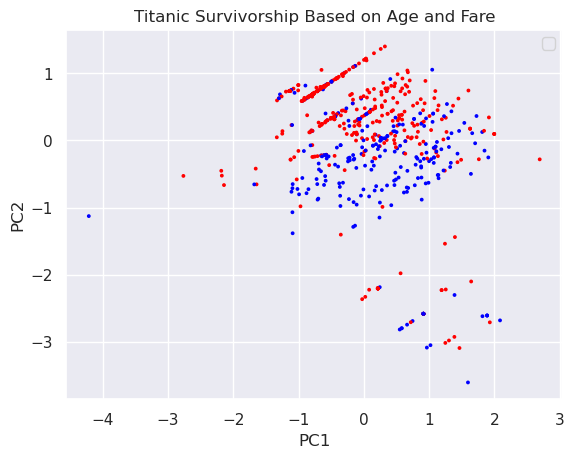

In [7]:
colors = ["Blue" if x == 1 else "Red" for x in PCA_train_y]

scatter = plt.scatter(PCA_train_X[:, 0], PCA_train_X[:, 1], c=colors, s = 3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Titanic Survivorship Based on Age and Fare")
plt.legend(handles=scatter.legend_elements()[0], labels=["Survived", "Died"])
plt.show()

We will continue with the data, as a lower fare seems to indicate a higher chance of death.

Now, we map data to X and y for use in training:

In [8]:
# Utility function to display the classification line:
def display_classification_line(weights, X, y, bias):
    t = np.linspace(min(X[:, 0]), max(X[:, 0]), 1000)
    y_t = (-weights[0]*t-bias)/weights[1]
    colors = ["Blue" if x == 1 else "Red" for x in y]
    plt.plot(t, y_t)
    plt.scatter(X[:, 0], X[:, 1], c = colors, s = 3)
    plt.show()

In [11]:
# Perceptron class implementation
class Perceptron():
    def __init__(self, _X):
        self.X = _X
        self.dim = np.shape(self.X)[1]
        self.num_elements = np.shape(self.X)[0]
        self.weights = np.random.rand(self.dim, 1)
        self.bias = np.random.rand(1)[0]

    def error(self, y_diff):
        return 1/4 * sum((y_diff[i])**2 for i in range(len(y_diff)))
    
    def predict(self, X):
        z = (self.weights.T @ X.T + self.bias)
        a = np.where(z < 0, -1, z)
        a = np.where(z >= 0, 1, a)
        return a[0]
    
    def update(self, y_diff, eta):
        for i in range(self.num_elements):
            self.weights += -eta * y_diff[i] * self.X[i:i+1, :].T
            self.bias += -eta * y_diff[i]

    def train(self, y_exact, eta = 1/2, epochs = 100):
        errors = []
        for _ in range(epochs):
            y_calc = self.predict(self.X)
            y_diff = y_calc - y_exact
            errors.append(self.error(y_diff))
            self.update(y_diff, eta)
        return errors

Now, we can train the data with eta = $1/2$:

In [80]:
perc = Perceptron(PCA_train_X)
errors = perc.train(PCA_train_y, eta = 0.01, epochs=100)

Calculate percent of training data correctly classified:

In [81]:
percent_PCA_train_correct = (len(PCA_train_X)-errors[-1]) / len(PCA_train_X)
number_PCA_train_correct = int(len(PCA_train_X)-errors[-1])

print(f"Percent of training predictions correct = {percent_PCA_train_correct*100.0:2.2f}%")
print(str(number_PCA_train_correct), "correctly classified out of", str(len(PCA_train_X)))

Percent of training predictions correct = 84.69%
526 correctly classified out of 622


Pretty good. Now display the classification line:

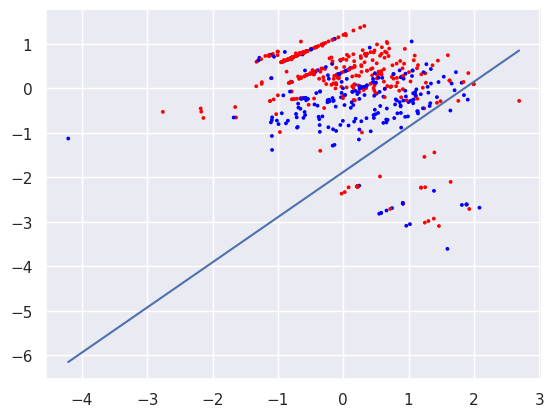

In [82]:
display_classification_line(perc.weights, PCA_train_X, PCA_train_y, perc.bias)

Now, predict testing data:

In [83]:
predictions = perc.predict(PCA_test_X)
predictions[predictions == -1] = 0
equal_preds = (predictions - PCA_test_y)
num_good_preds = (equal_preds == 0).sum()
percent_PCA_test_correct = num_good_preds / len(predictions)
number_PCA_test_correct = num_good_preds
print(f"Percent of testing predictions correct = {percent_PCA_test_correct*100.0:2.2f}%")
print(str(number_PCA_test_correct), "correctly classified out of", str(len(predictions)))

Percent of testing predictions correct = 59.55%
159 correctly classified out of 267


Now, we plot error over time (epochs):

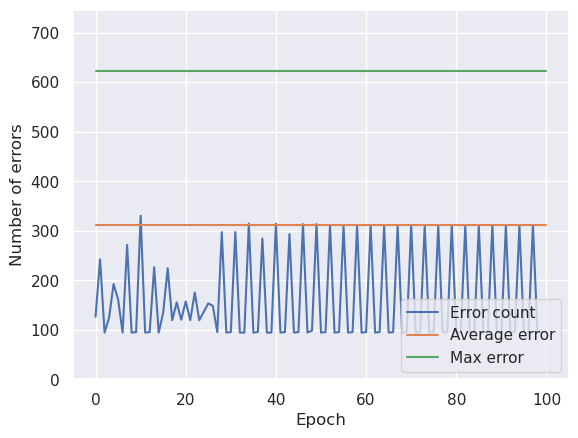

In [84]:
plt.ylim((0.0, len(PCA_train_X)*1.2))
plt.ylabel("Number of errors")
plt.xlabel("Epoch")
plt.plot(errors, label="Error count")
t = np.linspace(0, len(errors), 1000)
plt.plot(t, [len(PCA_train_X)/2 for ti in t], label="Average error")
plt.plot(t, [len(PCA_train_X) for ti in t], label="Max error")
plt.legend()
plt.show()


As seen here, the error oscillates a little below the average error. Thus, this data is not well modeled by the perceptron.